<a href="https://colab.research.google.com/github/LeyvinoBezerra/API-de-Consulta/blob/main/Aula_5_Regressao_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Montagem do Drive**

In [ ]:
#monte o drive caso precise usar/salvar arquivos do seu drive
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/AprendizadoMaquina

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AprendizadoMaquina


In [ ]:
#bibliotecas
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

### **Regressão com dados sintéticos**

In [ ]:
X = np.array([50, 50, 46, 95, 50, 5, 57, 42, 26, 72, 78, 60, 40, 17, 85])
y = np.array([50000, 54000, 50000, 189000, 55000, 40000, 59000, 42000, 47000, 78000, 119000, 95000, 49000, 29000, 130000])

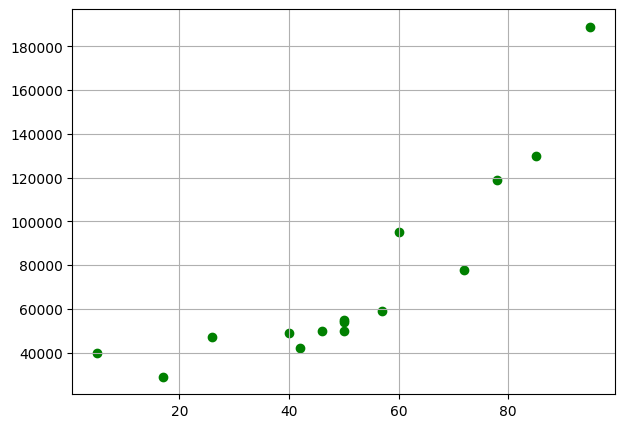

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='g')
plt.grid()
plt.show()

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [ ]:
X.shape

(15,)

In [ ]:
X

array([50, 50, 46, 95, 50,  5, 57, 42, 26, 72, 78, 60, 40, 17, 85])

In [ ]:
#Regressao Linear Simples
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
X = X.reshape(-1, 1)
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)



[1516.13788561]
-5731.639038313762


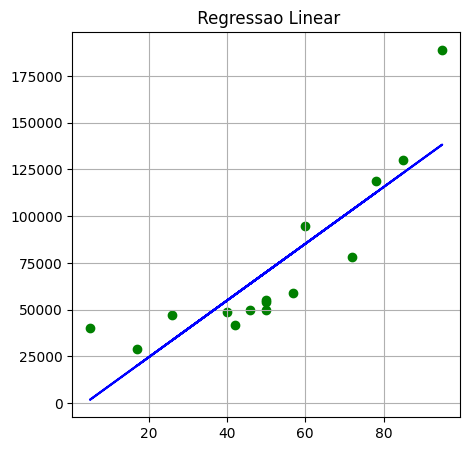

In [ ]:
linha_reg = X * reg.coef_ + reg.intercept_
plt.figure(figsize=(5, 5))
plt.scatter(X, y, color='g')
plt.plot(X, linha_reg, color='b')
plt.title(' Regressao Linear')
plt.grid()
plt.show()

###**Regressão Linear com Dataset California Housing**

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Variável	Descrição

* MedInc	Renda média das famílias na região
* HouseAge	Idade média das casas
* AveRooms	Número médio de cômodos por casa
* AveBedrms	Número médio de quartos por casa
* Population	População do distrito
* AveOccup	Ocupação média por residência
* Latitude, Longitude	Localização geográfica
* target	Valor médio das casas (em centenas de milhares)

In [ ]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
#Amostragem dos dados - Holdout
import pandas as pd
from sklearn.model_selection import train_test_split

X = pd.DataFrame(housing.data,columns=housing.feature_names)
y= pd.DataFrame(housing.target)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25)
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
11395,6.6324,22.0,7.129098,0.932377,1454.0,2.979508,33.73,-117.96
3745,4.2989,34.0,4.787659,1.052632,1150.0,2.087114,34.16,-118.40
20449,4.0474,22.0,4.745070,1.085915,2751.0,3.874648,34.28,-118.88
7530,3.1190,34.0,4.130890,1.047120,1041.0,5.450262,33.91,-118.23
8468,2.4550,8.0,3.543923,1.101387,7211.0,2.381440,33.91,-118.33


#Gradiente Descendente

### https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

In [ ]:
#Regressao Linear
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn import metrics
import numpy as np


Reg = LinearRegression() #inicializa o objeto da classe com valores default
Reg2 = SGDRegressor()

Reg.fit(X_train,y_train)
pred = Reg.predict(X_test) #executa a predição para os dados de teste
print(pred)


[[2.49844732]
 [2.82771618]
 [2.2053012 ]
 ...
 [3.94087084]
 [2.54063749]
 [0.76503571]]


In [ ]:
print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))
print('R2:', metrics.r2_score(y_test, pred))

MAE: 0.5284072230657539
MSE: 0.5114244329963196
RMSE: 0.7151394500349701
R2: 0.6118697484033715


#Regressão Linear com Validação Cruzada

In [ ]:
#Exemplo da aplicação do algoritmo LinearRegression com amostragem usando validação cruzada a partir da função cross_val_predict
#Lembrar que o cross_val_predict retorna os valores preditos pelo modelo para cada instância quando ela esteve no fold de teste
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn import metrics

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.DataFrame(housing.target, columns = housing.target_names)

predictedCV = cross_val_predict(Reg,X, y, cv=10)
print('MAE:', metrics.mean_absolute_error(y, predictedCV))
print('MSE:', metrics.mean_squared_error(y, predictedCV))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, predictedCV)))
print('R2:', metrics.r2_score(y, predictedCV))

scores = cross_val_score(Reg, X, y, cv=10, scoring='r2')
print(scores)
print(f"R2 Médio do cross_val_score: {scores.mean():.4f}")

MAE: 0.5445214393266329
MSE: 0.5509524296956593
RMSE: 0.7422616989281201
R2: 0.5862323566283527
[0.48254494 0.61416063 0.42274892 0.48178521 0.55705986 0.5412919
 0.47496038 0.45844938 0.48177943 0.59528796]
R2 Médio do cross_val_score: 0.5110


# Pre-processamento

In [ ]:
# Analisar se dataset tem dados faltantes
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


<Axes: >

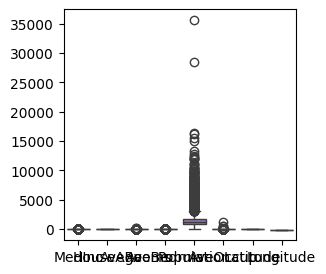

In [ ]:
#analisar se dataset tem outliers
import seaborn as sns
plt.figure(figsize=(3, 3))
sns.boxplot(data=X)

<Axes: >

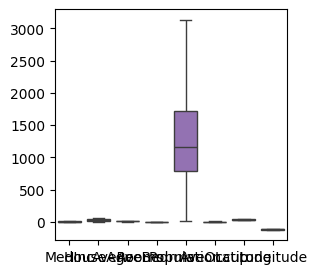

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#Tratar outliers com a regra da IQR
# para calcular obs limites só deve-se levar em considerar o X de treino
X_train_out = X_train.copy()
q1 = X_train.quantile(0.25)  # primeiro quartil
q3 = X_train.quantile(0.75)  # terceiro quartil
iqr = q3 - q1
lLim = q1 - 1.5 * iqr
hLim = q3 + 1.5 * iqr
#print(hLim)

# loop para todas as colunas de X
for col in X_train.columns:
    X_train_out.loc[X_train_out[col] < lLim[col], col] = lLim[col]
    X_train_out.loc[X_train_out[col] > hLim[col], col] = hLim[col]


for col in X_test.columns:
    X_test.loc[X_test[col] < lLim[col], col] = lLim[col]
    X_test.loc[X_test[col] > hLim[col], col] = hLim[col]

plt.figure(figsize=(3, 3))
sns.boxplot(data=X_train_out)

# Regressão Linear com dados sem outliers

In [ ]:
Reg.fit(X_train_out,y_train)
pred = Reg.predict(X_test) #executa a predição para os dados de teste
print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))
print('R2:', metrics.r2_score(y_test, pred))

MAE: 0.4972261040399565
MSE: 0.4551229628753441
RMSE: 0.6746280181517398
R2: 0.6619617328765182


# Regressão Linear com dados padronizados

<Axes: >

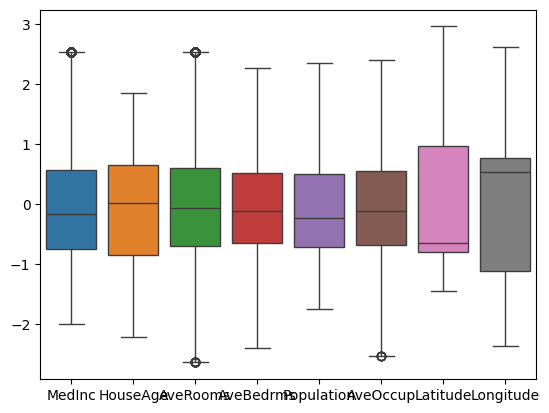

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Padronizando o TREINO
# Use fit_transform apenas no treino após tratamento de outliers
X_train_pad = scaler.fit_transform(X_train_out.copy())
X_train_pad  = pd.DataFrame(X_train_pad ,columns=housing.feature_names)

# 2. Padronizando o TESTE
# IMPORTANTE: Use apenas .transform()
X_test_pad = scaler.transform(X_test)
X_test_pad = pd.DataFrame(X_test_pad, columns=housing.feature_names)


sns.boxplot(data=X_train_pad)

In [ ]:
Reg.fit(X_train_pad,y_train)
pred = Reg.predict(X_test_pad) #executa a predição para os dados de teste
print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))
print('R2:', metrics.r2_score(y_test, pred))

MAE: 0.4972261040399555
MSE: 0.4551229628753442
RMSE: 0.6746280181517398
R2: 0.661961732876518


# Regressão Linear com Normalização

MAE: 0.49722610403995543
MSE: 0.4551229628753442
RMSE: 0.6746280181517398
R2: 0.661961732876518


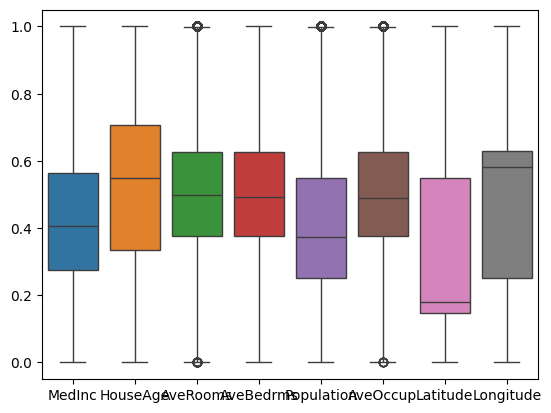

In [ ]:
# Normalizando os dados
from sklearn.preprocessing import MinMaxScaler

scaler2 = MinMaxScaler()

# 1. Padronizando o TREINO
# Use fit_transform apenas no treino após tratamento de outliers
X_train_nor = scaler2.fit_transform(X_train_out.copy())
X_train_nor = pd.DataFrame(X_train_nor,columns=housing.feature_names)

# 2. Padronizando o TESTE
# IMPORTANTE: Use apenas .transform()
X_test_nor = scaler2.transform(X_test)
X_test_nor = pd.DataFrame(X_test_nor, columns=housing.feature_names)

sns.boxplot(data=X_train_nor)
Reg.fit(X_train_nor,y_train)
pred = Reg.predict(X_test_nor) #executa a predição para os dados de teste

print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))
print('R2:', metrics.r2_score(y_test, pred))

## Analisar Correlação dos atributos

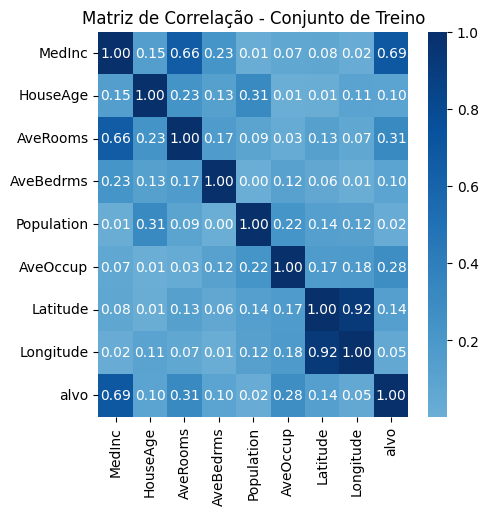

In [ ]:
# 1. Unir X_train (Antes de Padronizar/Normalizar) e y_train em um único DataFrame de análise para  ver a correlação das features com o alvo
df_analise = X_train_out.copy()
df_analise['alvo'] = y_train

# 2. Calcular a matriz de correlação (Pearson por padrão)
corr_matrix = df_analise.corr().abs()

# 3. Criar o Heatmap para visualização técnica
plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', center=0)
plt.title("Matriz de Correlação - Conjunto de Treino")
plt.show()

In [ ]:
# 4. Remover do treino E do teste

X_train_filtered = X_train_out.drop(columns=['AveRooms'])
X_test_filtered = X_test.drop(columns=['AveRooms'])

#X_train_filtered = X_train_out.drop(columns=['Longitude'])
#X_test_filtered = X_test.drop(columns=['Longitude'])

#X_train_filtered = X_train_out.drop(columns=['Longitude','AveRooms'])
#X_test_filtered =X_test.drop(columns=['Longitude','AveRooms'])


Reg.fit(X_train_filtered,y_train)
pred_filtered = Reg.predict(X_test_filtered ) #executa a predição para os dados de teste
print('MAE:', metrics.mean_absolute_error(y_test, pred_filtered))
print('MSE:', metrics.mean_squared_error(y_test, pred_filtered))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_filtered)))
print('R2:', metrics.r2_score(y_test, pred_filtered))

MAE: 0.5031350425231909
MSE: 0.46001771884169346
RMSE: 0.6782460606901403
R2: 0.6583261992738987


In [ ]:
#Usando apenas a variavel mais correlacionada

Reg.fit(X_train_out[['MedInc']],y_train)
pred_filtered = Reg.predict(X_test[['MedInc']] )
print('MAE:', metrics.mean_absolute_error(y_test, pred_filtered))
print('MSE:', metrics.mean_squared_error(y_test, pred_filtered))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_filtered)))
print('R2:', metrics.r2_score(y_test, pred_filtered))

MAE: 0.6348152020957892
MSE: 0.7124758747021217
RMSE: 0.8440828600926107
R2: 0.4708152967496868


## PCA
Antes do PCA, deve-se tratar outliers e fazer padronização.

In [ ]:
# dataset original tem 8 atributos
X_train_pad.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [ ]:
from sklearn.decomposition import PCA

 #O atributo n_components representa quantos atributos queremos deixar
 #usando ’mle’ o Minka’s MLE será utilizado para escolher a melhor dimensão a ser mantida

pca = PCA(n_components='mle')
#pca = PCA(n_components=5)
#pca = PCA(0.9)

# Ajusta apenas no treino
X_train_pca = pca.fit_transform(X_train_pad)

# Aplica no teste o que aprendeu no treino
X_test_pca = pca.transform(X_test_pad)

#df_pca = pca.fit_transform(dfnor)
df_pca = pd.DataFrame(X_train_pca)
df_pca.head()

,0,1,2,3,4,5,6
0,-1.141633,-0.519221,1.090007,-0.035419,-0.565467,0.056985,0.863261
1,-1.796262,2.515133,-2.777387,0.478890,0.549562,0.542834,0.585457
2,-1.731245,-1.419451,-0.504095,-0.692256,0.760209,-0.479524,-0.167255
3,0.679658,2.596668,0.576374,-1.097530,-0.886513,-1.095881,-0.411961
4,2.120158,2.303661,1.384112,-0.481411,0.668363,0.243229,-0.682643


In [ ]:
print(pca.explained_variance_ratio_)

[0.26076713 0.21965283 0.1597134  0.14507494 0.10632561 0.07480268
 0.02763662]


In [ ]:
print(pca.components_)

[[ 7.03402940e-02  8.61667491e-02  1.81255401e-01  6.14464558e-02
  -2.47124537e-01 -2.73238953e-01  6.39046645e-01 -6.37877473e-01]
 [ 6.40077150e-01 -3.84379008e-01  6.44762185e-01  1.72111388e-02
   1.13451860e-01 -1.16498633e-02 -7.94369038e-02  8.49838583e-02]
 [ 3.18967874e-01  5.44002575e-01  7.06602956e-02 -4.75965126e-01
  -5.43401802e-01 -1.14690966e-01 -2.14739369e-01  1.27406761e-01]
 [-1.50359582e-01  1.38957440e-04  1.35537793e-01  6.61272012e-01
  -4.05914233e-01 -5.00203117e-01 -1.93561666e-01  2.63258747e-01]
 [-7.24484760e-02  3.15534487e-01  3.12639007e-01  3.91300948e-01
  -2.20819511e-01  7.68770918e-01  6.53066059e-02 -1.71665801e-02]
 [ 2.13018512e-01  6.58174634e-01  5.97030596e-02  2.58332317e-01
   6.25806193e-01 -2.21189612e-01 -7.58355375e-02 -6.94259237e-02]
 [-5.99379565e-01  1.09288615e-01  6.24411591e-01 -3.31953510e-01
   1.59377202e-01 -1.47667279e-01  1.48151763e-01  2.44052261e-01]]


In [ ]:
Reg.fit(X_train_pca,y_train)
pred_filtered = Reg.predict(X_test_pca )
print('MAE:', metrics.mean_absolute_error(y_test, pred_filtered))
print('MSE:', metrics.mean_squared_error(y_test, pred_filtered))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_filtered)))
print('R2:', metrics.r2_score(y_test, pred_filtered))

MAE: 0.5119939418022286
MSE: 0.48885517724162436
RMSE: 0.6991817912686402
R2: 0.6369074503622378


### Pipeline

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

### Pipeline sem tratamento de outliers

In [ ]:
#Pipeline sem tratamento de outliers

# 1. Preparação dos dados (Exemplo com X e y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# 2. Construção do Pipeline
# O Pipeline executará as etapas na ordem: Padronizar -> Reduzir Dimensões -> Estimar
pipeline_ia = Pipeline([
    ('scaler', StandardScaler()),       # O PCA exige dados na mesma escala
    ('pca', PCA(n_components='mle')),    # Mantém componentes que explicam 95% da variância
    ('regressor', LinearRegression())   # O modelo final
])

# 3. Treinamento (Fit)
# O fit aprenderá a média/desvio (scaler) e os componentes (pca) APENAS no treino
pipeline_ia.fit(X_train, y_train)

# 4. Predição e Avaliação
y_pred = pipeline_ia.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# 5. Dica: Para ver quantos componentes o PCA escolheu
n_componentes = pipeline_ia.named_steps['pca'].n_components_
print(f"O PCA reduziu o dataset para {n_componentes} componentes principais.")

R² Score: 0.0399
MAE: 0.5471
O PCA reduziu o dataset para 7 componentes principais.


### Pipeline incluindo retirada de outliers

In [ ]:
# Herdando classes base do Scikit-Learn para criar um componente personalizado.
# BaseEstimator: Garante que a classe possa ser usada em otimizações (como GridSearchCV).
# TransformerMixin: Adiciona automaticamente o método fit_transform() para facilitar o fluxo.

from sklearn.base import BaseEstimator, TransformerMixin

class IQRWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # O fator 1.5 agora é fixo aqui dentro
        self.factor = 1.5
        self.lLim = None
        self.hLim = None

    def fit(self, X, y=None):
        # Calcula os limites usando o 1.5 fixo
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lLim = q1 - self.factor * iqr
        self.hLim = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Aplica a lógica de achatamento que você criou
        for col in X_copy.columns:
            X_copy.loc[X_copy[col] < self.lLim[col], col] = self.lLim[col]
            X_copy.loc[X_copy[col] > self.hLim[col], col] = self.hLim[col]
        return X_copy

In [ ]:
from imblearn.pipeline import Pipeline # Importante: usar o pipeline do imblearn para tratar outliers
from imblearn import FunctionSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression,SGDRegressor
import numpy as np
import warnings
warnings.filterwarnings("ignore")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# 1. Montamos o Pipeline "Blindado"
pipeline_ia = Pipeline([
    ('outlier_remover', IQRWinsorizer()), # Passo 1: Limpa o treino
    ('scaler', StandardScaler()),                             # Passo 2: Padroniza
    ('pca', PCA(n_components='mle')),                         # Passo 3: Reduz
    ('regressor', SGDRegressor())                         # Passo 4: Estima
])

# 2. Aplicamos a Validação Cruzada
# Aqui o Scikit-Learn vai dividir o X em 10 partes (cv=10)
# Para cada parte, ele vai rodar TODO o pipeline (limpar, escalar, PCA e treinar)
scores_r2 = cross_val_score(pipeline_ia, X, y, cv=5, scoring='r2')
print(f"R² CV: {scores_r2.mean():.4f} (+/- {scores_r2.std():.4f})")

# 2. ou Holdout Fit e Predict
pipeline_ia.fit(X_train, y_train)
y_pred = pipeline_ia.predict(X_test)
print(f"R² Holdout: {r2_score(y_test, y_pred):.4f}")

R² CV: 0.5870 (+/- 0.0314)
R² Holdout: 0.6426
